In [2]:
#Import Kaggle dataset
from google.colab import userdata
import os

os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')


In [3]:
# First dataset
!apt-get install tree
!kaggle datasets download -d ayuraj/asl-dataset
! unzip -q "/content/asl-dataset.zip"

!kaggle datasets download -d grassknoted/asl-alphabet
! unzip -q "/content/asl-alphabet.zip"

!mv asl_alphabet_train/asl_alphabet_train/* asl_alphabet_train/
!rm -r asl_alphabet_train/asl_alphabet_train/
!mv asl_alphabet_test/asl_alphabet_test/* asl_alphabet_test/
!rm -r asl_alphabet_test/asl_alphabet_test/

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 0s (121 kB/s)
Selecting previously unselected package tree.
(Reading database ... 125082 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...
Dataset URL: https://www.kaggle.com/datasets/ayuraj/asl-dataset
License(s): CC0-1.0
  0% 0.00/56.9M [00:00<?, ?B/s]
100% 56.9M/56.9M [00:00<00:00, 1.45GB/s]
Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet
License(s): GPL-2.0
 98% 1.01G/1.03G [00:07<00:00, 110MB/s]
1

In [4]:
!tree -L 2

.
├── asl_alphabet_test
│   ├── A_test.jpg
│   ├── B_test.jpg
│   ├── C_test.jpg
│   ├── D_test.jpg
│   ├── E_test.jpg
│   ├── F_test.jpg
│   ├── G_test.jpg
│   ├── H_test.jpg
│   ├── I_test.jpg
│   ├── J_test.jpg
│   ├── K_test.jpg
│   ├── L_test.jpg
│   ├── M_test.jpg
│   ├── nothing_test.jpg
│   ├── N_test.jpg
│   ├── O_test.jpg
│   ├── P_test.jpg
│   ├── Q_test.jpg
│   ├── R_test.jpg
│   ├── space_test.jpg
│   ├── S_test.jpg
│   ├── T_test.jpg
│   ├── U_test.jpg
│   ├── V_test.jpg
│   ├── W_test.jpg
│   ├── X_test.jpg
│   ├── Y_test.jpg
│   └── Z_test.jpg
├── asl_alphabet_train
│   ├── A
│   ├── B
│   ├── C
│   ├── D
│   ├── del
│   ├── E
│   ├── F
│   ├── G
│   ├── H
│   ├── I
│   ├── J
│   ├── K
│   ├── L
│   ├── M
│   ├── N
│   ├── nothing
│   ├── O
│   ├── P
│   ├── Q
│   ├── R
│   ├── S
│   ├── space
│   ├── T
│   ├── U
│   ├── V
│   ├── W
│   ├── X
│   ├── Y
│   └── Z
├── asl-alphabet.zip
├── asl_dataset
│   ├── 0
│   ├── 1
│   ├── 2
│   ├── 3
│   ├── 4
│   ├── 5
│   ├── 6
│ 

In [5]:
# =================== ASL Random BG + Combine + +20% Augmentation + Visualization (no nesting checks) ===================
import os, math, uuid, random, shutil
from pathlib import Path
from typing import List, Tuple, Optional
from tqdm import tqdm

import numpy as np
import cv2
from PIL import Image

import torch
from torchvision import transforms
import matplotlib.pyplot as plt


class ASLPipeline:
    """
    Pipeline for ASL dataset preparation:
      1. make_random_bg_dataset()   → Add random RGB background (GrabCut for any background)
      2. combine_datasets()         → Merge original + random-bg datasets
      3. augment_20_percent()       → Add ~20% more images using torchvision (safe for ASL)
      Each step includes 3x3 visualization.

    NOTE: This version intentionally omits any "nesting" safeguards.
    """

    def __init__(self, target_size=(224, 224), seed=42, pastel_bg=False):
        self.target_size = target_size
        self.valid_exts = (".jpg", ".jpeg", ".png")
        self.pastel_bg = pastel_bg
        if seed is not None:
            random.seed(seed)
            torch.manual_seed(seed)

        # Augmentation pipeline (ASL-safe — no flips)
        class AddGaussianNoise:
            def __init__(self, mean=0.0, std=0.02):
                self.mean, self.std = mean, std
            def __call__(self, img_tensor):
                noise = torch.randn_like(img_tensor) * self.std + self.mean
                return torch.clamp(img_tensor + noise, 0.0, 1.0)

        self.augment = transforms.Compose([
            transforms.Resize(self.target_size, interpolation=Image.BILINEAR),
            transforms.RandomApply([transforms.ColorJitter(
                brightness=0.25, contrast=0.25, saturation=0.15, hue=0.02)], p=0.8),
            transforms.RandomAffine(degrees=10, translate=(0.05, 0.05),
                                    scale=(0.95, 1.05), shear=(-5, 5)),
            transforms.RandomPerspective(distortion_scale=0.25, p=0.4),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
            transforms.ToTensor(),
            AddGaussianNoise(mean=0.0, std=0.015),
            transforms.ToPILImage()
        ])

    # ---------------- Utility Methods ----------------
    def _is_image(self, p: Path):
        return p.is_file() and p.suffix.lower() in self.valid_exts

    def _safe_mkdir(self, p: Path):
        p.mkdir(parents=True, exist_ok=True)

    def _grabcut_mask(self, img_bgr):
        """Foreground mask using GrabCut (works with any background)."""
        h, w = img_bgr.shape[:2]
        mask = np.zeros((h, w), np.uint8)
        bgd, fgd = np.zeros((1, 65), np.float64), np.zeros((1, 65), np.float64)
        pad = max(6, min(h, w) // 20)
        rect = (pad, pad, w - 2 * pad, h - 2 * pad)
        try:
            cv2.grabCut(img_bgr, mask, rect, bgd, fgd, 3, mode=cv2.GC_INIT_WITH_RECT)
            fg = (mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD)
        except Exception:
            fg = np.ones((h, w), bool)
        return fg

    def _random_bg(self, shape):
        if not self.pastel_bg:
            return np.random.randint(0, 256, shape, dtype=np.uint8)
        base = np.random.randint(100, 256, (1, 1, 3), dtype=np.uint8)
        noise = np.random.randint(-30, 30, shape, dtype=np.int16)
        return np.clip(base + noise, 0, 255).astype(np.uint8)

    def _show_grid(self, imgs_labels, title="Preview"):
        """Visualize up to 9 samples (3x3)."""
        if not imgs_labels:
            print(f"{title}: no images to show.")
            return
        plt.figure(figsize=(10, 10))
        for i, (img, lbl) in enumerate(imgs_labels[:9]):
            plt.subplot(3, 3, i + 1)
            plt.imshow(img)
            plt.title(lbl, fontsize=14, weight="bold")
            plt.axis("off")
        plt.suptitle(title, fontsize=16)
        plt.tight_layout()
        plt.show()

    # ---------------- Step 1: Random RGB background ----------------
    def make_random_bg_dataset(self, in_dir, out_dir=None):
        """
        Apply random RGB backgrounds to all images.
        Supports:
          - Labeled: in_dir/Label/*.jpg
          - Flat   : in_dir/*.jpg
        """
        src = Path(in_dir).resolve()
        out = Path(out_dir or f"{in_dir}_with_random_rgb_values").resolve()
        self._safe_mkdir(out)

        label_dirs = [d for d in src.iterdir() if d.is_dir()]
        labeled = bool(label_dirs)
        if labeled:
            for d in label_dirs:
                self._safe_mkdir(out / d.name)

        samples = []
        if labeled:
            for d in tqdm(label_dirs, desc=f"RandomBG {src.name}"):
                for f in d.iterdir():
                    if not self._is_image(f):
                        continue
                    img_bgr = cv2.imread(str(f))
                    if img_bgr is None:
                        continue
                    img_bgr = cv2.resize(img_bgr, self.target_size)
                    mask = self._grabcut_mask(img_bgr)
                    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
                    bg = self._random_bg(img_rgb.shape)
                    comp = np.where(mask[..., None], img_rgb, bg).astype(np.uint8)

                    dst = out / d.name / f.name
                    if dst.exists():
                        dst = out / d.name / f"{f.stem}_rb_{uuid.uuid4().hex[:6]}{f.suffix}"
                    cv2.imwrite(str(dst), cv2.cvtColor(comp, cv2.COLOR_RGB2BGR))

                    if len(samples) < 9 and random.random() < 0.03:
                        samples.append((Image.fromarray(comp), d.name))
        else:
            for f in tqdm(src.iterdir(), desc=f"RandomBG {src.name}"):
                if not self._is_image(f):
                    continue
                img_bgr = cv2.imread(str(f))
                if img_bgr is None:
                    continue
                img_bgr = cv2.resize(img_bgr, self.target_size)
                mask = self._grabcut_mask(img_bgr)
                img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
                bg = self._random_bg(img_rgb.shape)
                comp = np.where(mask[..., None], img_rgb, bg).astype(np.uint8)

                dst = out / f.name
                cv2.imwrite(str(dst), cv2.cvtColor(comp, cv2.COLOR_RGB2BGR))

                if len(samples) < 9 and random.random() < 0.1:
                    samples.append((Image.fromarray(comp), f.name))

        print(f"✅ Random background dataset saved: {out}")
        self._show_grid(samples, f"Random RGB Backgrounds: {src.name}")
        return str(out)

    # ---------------- Step 2: Combine datasets ----------------
    def combine_datasets(self, src_dirs, combined_dir):
        """Combine multiple datasets into one (avoids overwriting by renaming)."""
        out = Path(combined_dir).resolve()
        self._safe_mkdir(out)

        # Collect label names from sources (if any)
        label_set = set()
        for s in src_dirs:
            for d in os.listdir(s):
                if (Path(s) / d).is_dir():
                    label_set.add(d)
        for lbl in sorted(label_set):
            self._safe_mkdir(out / lbl)

        preview = []
        for src in src_dirs:
            base = Path(src).name
            print(f"📂 Copying from {base}...")
            # If labeled
            labeled_subdirs = [d for d in (Path(src)).iterdir() if d.is_dir()]
            if labeled_subdirs:
                for d in tqdm(sorted(labeled_subdirs), desc=f"{base}"):
                    dst_dir = out / d.name
                    self._safe_mkdir(dst_dir)
                    for f in d.iterdir():
                        if not self._is_image(f):
                            continue
                        dst = dst_dir / f.name
                        if dst.exists():
                            dst = dst_dir / f"{base}_{f.name}"
                        shutil.copy2(f, dst)
                        if len(preview) < 9 and random.random() < 0.03:
                            preview.append((Image.open(dst).convert("RGB"), d.name))
            else:
                # flat folder
                for f in tqdm([x for x in Path(src).iterdir() if self._is_image(x)], desc=f"{base}"):
                    dst = out / f.name
                    if dst.exists():
                        dst = out / f"{base}_{f.name}"
                    shutil.copy2(f, dst)
                    if len(preview) < 9 and random.random() < 0.03:
                        preview.append((Image.open(dst).convert("RGB"), f.name))

        print(f"✅ Combined dataset saved: {out}")
        self._show_grid(preview, "Combined Dataset Preview")
        return str(out)

    # ---------------- Step 3: Augment +20% ----------------
    def augment_20_percent(self, in_dir, out_dir=None, include_originals=True):
        """Apply torchvision augmentation to add ~+20% new images."""
        src = Path(in_dir).resolve()
        out = Path(out_dir or f"{in_dir}_augmented").resolve()
        self._safe_mkdir(out)

        labeled_dirs = [d for d in src.iterdir() if d.is_dir()]
        labeled = bool(labeled_dirs)
        if labeled:
            for d in labeled_dirs:
                self._safe_mkdir(out / d.name)

        # Gather files
        if labeled:
            files = [(d.name, f) for d in labeled_dirs for f in d.iterdir() if self._is_image(f)]
        else:
            files = [("", f) for f in src.iterdir() if self._is_image(f)]
        base_total = len(files)
        print(f"Found {base_total} images in {src.name}")

        # Copy originals first (optional)
        copied = 0
        if include_originals:
            print("Copying originals...")
            for lbl, f in tqdm(files):
                try:
                    img = Image.open(f).convert("RGB").resize(self.target_size, Image.BILINEAR)
                    if labeled:
                        dst = out / lbl / f.name
                    else:
                        dst = out / f.name
                    if dst.exists():
                        dst = dst.with_name(dst.stem + f"_orig_{uuid.uuid4().hex[:6]}" + f.suffix.lower())
                    img.save(dst, quality=95)
                    copied += 1
                except Exception as e:
                    print(f"Skip {f}: {e}")

        to_add = int(math.ceil(base_total * 0.20))
        print(f"Augmenting +{to_add} images (~20%)...")

        # Create augmentations
        added_preview = []
        made = 0
        if labeled:
            # balanced by label
            per_label = {}
            for d in labeled_dirs:
                per_label[d.name] = [f for f in d.iterdir() if self._is_image(f)]
            per_label_add = {k: int(math.ceil(len(v) * 0.20)) for k, v in per_label.items()}
            drift = to_add - sum(per_label_add.values())
            keys = list(per_label_add.keys())
            i = 0
            while drift != 0 and keys:
                per_label_add[keys[i % len(keys)]] += 1 if drift > 0 else -1
                drift += -1 if drift > 0 else 1
                i += 1

            for lbl, lst in tqdm(per_label.items(), desc="Augmenting per label"):
                need = max(0, per_label_add[lbl])
                if need == 0 or not lst:
                    continue
                idx = 0
                while need > 0 and made < to_add:
                    f = lst[idx % len(lst)]; idx += 1
                    try:
                        base = Image.open(f).convert("RGB")
                        aug_img = self.augment(base)
                        new_name = f"{Path(f).stem}_aug_{uuid.uuid4().hex[:8]}.jpg"
                        dst = out / lbl / new_name
                        aug_img.save(dst, quality=95)
                        made += 1; need -= 1
                        if len(added_preview) < 9 and random.random() < 0.03:
                            added_preview.append((aug_img, lbl))
                    except Exception:
                        pass
                    if idx > 3 * len(lst):
                        break
        else:
            lst = [f for _, f in files]
            idx = 0
            while made < to_add and lst:
                f = lst[idx % len(lst)]; idx += 1
                try:
                    base = Image.open(f).convert("RGB")
                    aug_img = self.augment(base)
                    new_name = f"{Path(f).stem}_aug_{uuid.uuid4().hex[:8]}.jpg"
                    dst = out / new_name
                    aug_img.save(dst, quality=95)
                    made += 1
                    if len(added_preview) < 9 and random.random() < 0.03:
                        added_preview.append((aug_img, Path(f).stem))
                except Exception:
                    pass
                if idx > 3 * len(lst):
                    break

        print(f"✅ Augmentation complete: {out} | Copied: {copied if include_originals else 0}, Augmented: {made}")
        self._show_grid(added_preview, "Augmented (+20%) Preview")
        return str(out)


RandomBG asl_dataset: 100%|██████████| 37/37 [07:06<00:00, 11.52s/it]


✅ Random background dataset saved: /content/asl_dataset_with_random_rgb_values


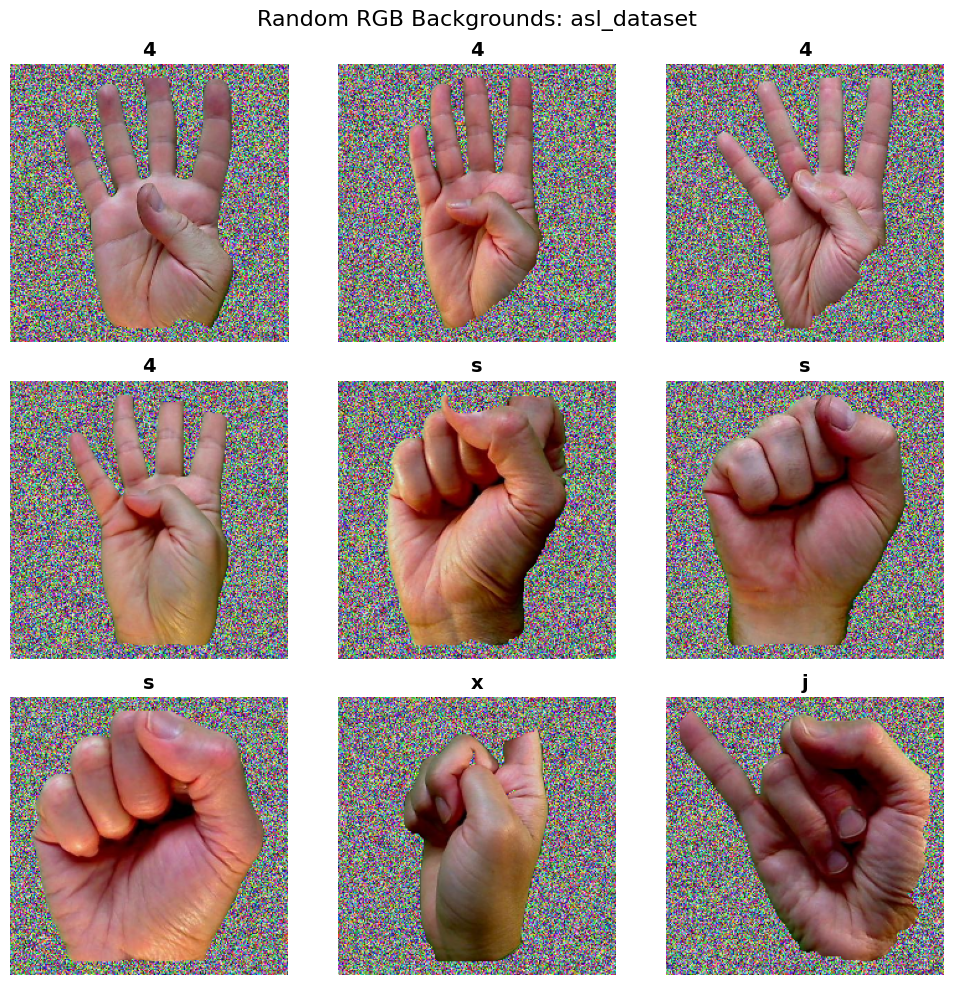

📂 Copying from asl_dataset...


asl_dataset: 100%|██████████| 37/37 [00:01<00:00, 34.02it/s]


📂 Copying from asl_dataset_with_random_rgb_values...


asl_dataset_with_random_rgb_values: 100%|██████████| 37/37 [00:01<00:00, 20.07it/s]


✅ Combined dataset saved: /content/asl_dataset_combined


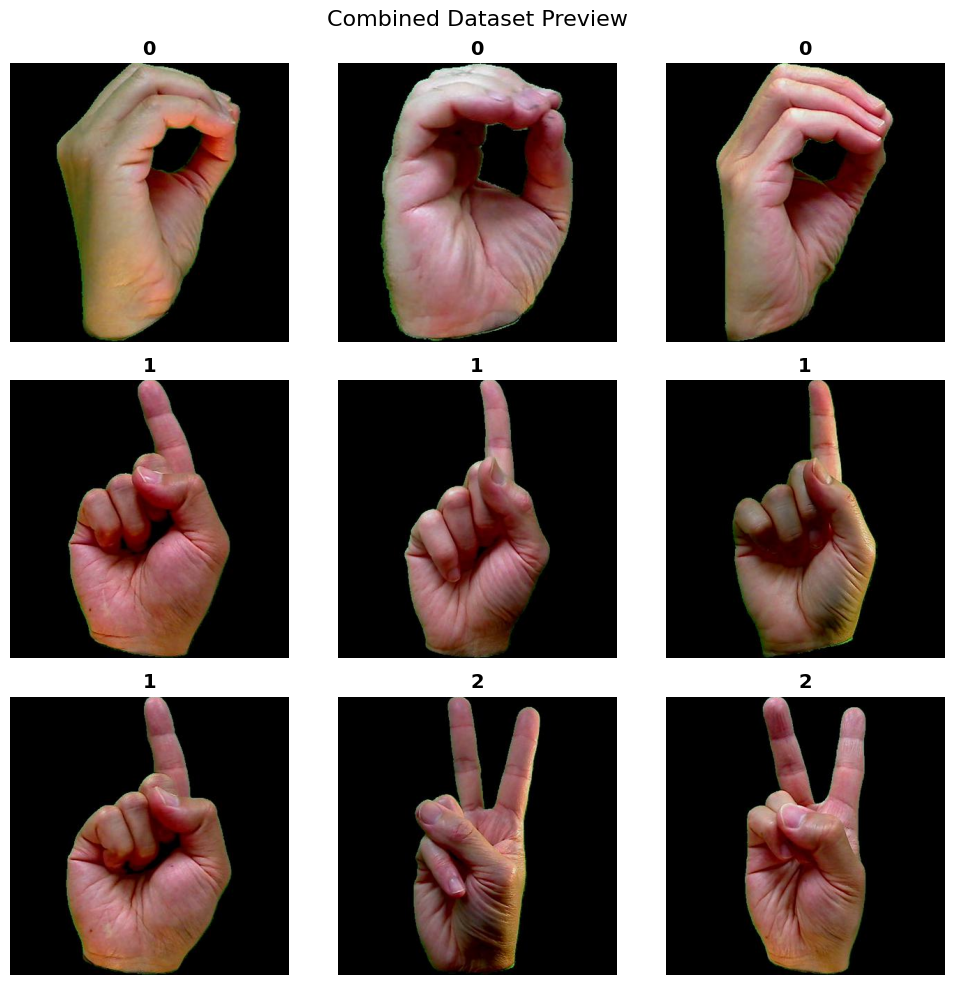

Found 5030 images in asl_dataset_combined
Copying originals...


100%|██████████| 5030/5030 [00:19<00:00, 254.45it/s]


Augmenting +1006 images (~20%)...


Augmenting per label: 100%|██████████| 37/37 [00:19<00:00,  1.94it/s]


✅ Augmentation complete: /content/asl_dataset_combined_augmented | Copied: 5030, Augmented: 1006


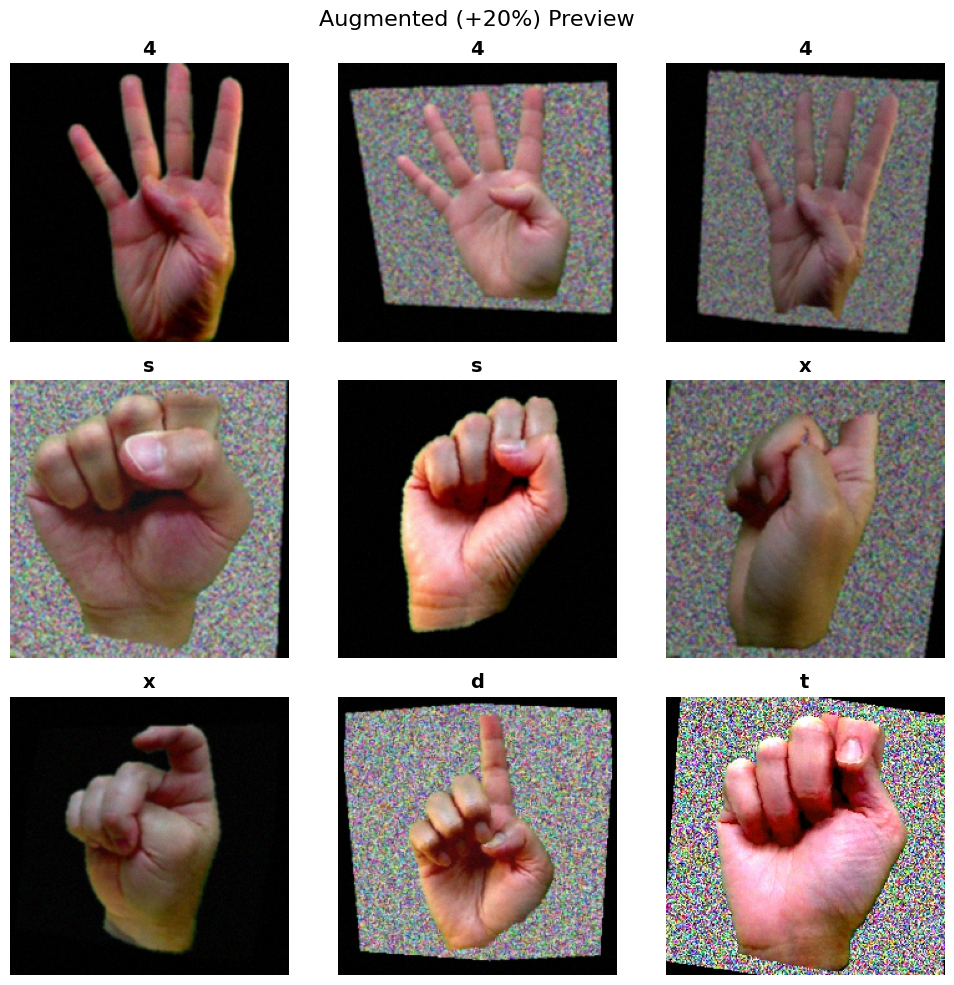

In [6]:
# =========================== EXAMPLE USAGE ===========================
# (replace with your own flattened dirs)
train_dir = "/content/asl_dataset"

pipe = ASLPipeline(target_size=(224, 224), pastel_bg=False)

# Step 1: random RGB backgrounds
train_rand = pipe.make_random_bg_dataset(train_dir)  # -> /content/asl_alphabet_train_with_random_rgb_values

# Step 2: combine original + random-background datasets
train_comb = pipe.combine_datasets([train_dir, train_rand], f"{train_dir}_combined")

# Step 3: augment +20%
train_aug = pipe.augment_20_percent(train_comb)      # -> /content/asl_alphabet_train_combined_augmented


# Vision Transfomer

Transformer for CV

![](https://drive.google.com/uc?export=view&id=19ZbTiRydCvsWg5dZXVJsuY2D6y7N3HFg)


![](https://drive.google.com/uc?export=view&id=15ZDgQ2fBMkReXxBwvX3eEa4wAsD407U7)

![](https://drive.google.com/uc?export=view&id=1WlKq6shzl4JjpQ7JZR0cW0B7hjJOcQUp)

